In [91]:
import sys
import os
from pathlib import Path
root = Path().resolve().parent.parent
sys.path.append(str(root))  # Add the root of the |project to the local path

In [92]:
import numpy as np
import numpy.linalg as la
import pandas as pd
import matplotlib.pyplot as plt
import numpy.random as rand
# import NSMap as ns
from mpl_toolkits.axes_grid1 import make_axes_locatable
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
import matplotlib.colors as colors
import src.NonstationarityTest as nt
import src.NSHyperparameterEstimation as nhe
import json

# %matplotlib notebook
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
filename = "../../datasets/baltic_sea_mesocosm_transformed.csv"

df = pd.read_csv(filename, encoding="utf-8", na_filter=False)
table = df.to_numpy()

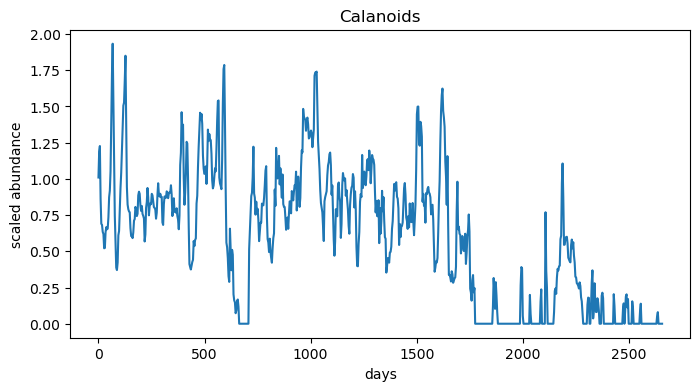

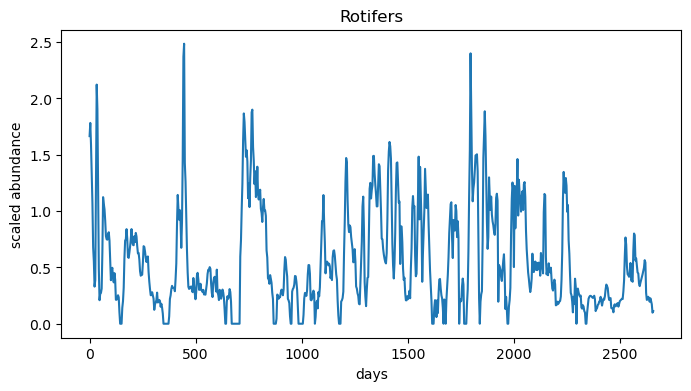

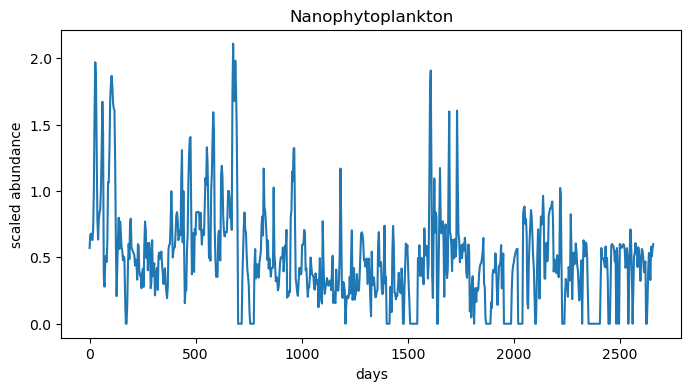

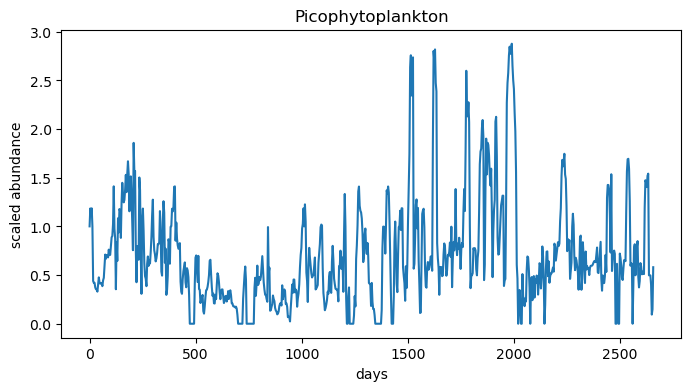

In [4]:
for i in range(4):
    fig, ax = plt.subplots(1,figsize=(8,4))
    ax.set_title(df.columns[i+1])
    ax.plot(table[:,0],table[:,i+1])
    ax.set_ylabel("scaled abundance")
    ax.set_xlabel("days")
    plt.show()

# Tau Determination
To determine the appropriate tau, a balance which maximizes forecast skill while minimizing autocorrelation must be found. We compute the optimal r^2 and autocorrelation for each lag, and find that tau=4 gives the best balance.

In [5]:
E_max = 6
taus = np.arange(1,7)
r_sqrd_table = np.zeros((len(taus),4))

In [6]:
""" uncomment to run for yourself
for i, series in enumerate(table.T[1:]):
    r_sqrds = [ns.get_delta_agg(series, E_max, tau=tau,
                             return_forecast_skill=True)[2] 
                   for tau in taus]
    r_sqrd_table[:,i] = r_sqrds
    
np.savetxt("../results/baltic_sea_multiwindow/baltic_sea_rsqrd_vs_tau.csv", r_sqrd_table, delimiter=",")
"""

' uncomment to run for yourself\nfor i, series in enumerate(table.T[1:]):\n    r_sqrds = [ns.get_delta_agg(series, E_max, tau=tau,\n                             return_forecast_skill=True)[2] \n                   for tau in taus]\n    r_sqrd_table[:,i] = r_sqrds\n\nnp.savetxt("../results/baltic_sea_multiwindow/baltic_sea_rsqrd_vs_tau.csv", r_sqrd_table, delimiter=",")\n'

In [7]:
# Check Autocorrelation

taus = np.arange(1,7)
autocorr_table = np.zeros((len(taus),4))

for i, series in enumerate(table.T[1:]):
    autocorr_table[:,i] = np.array([np.corrcoef(series[tau:],
                                                series[:-tau])[0,1]
                                  for tau in taus])

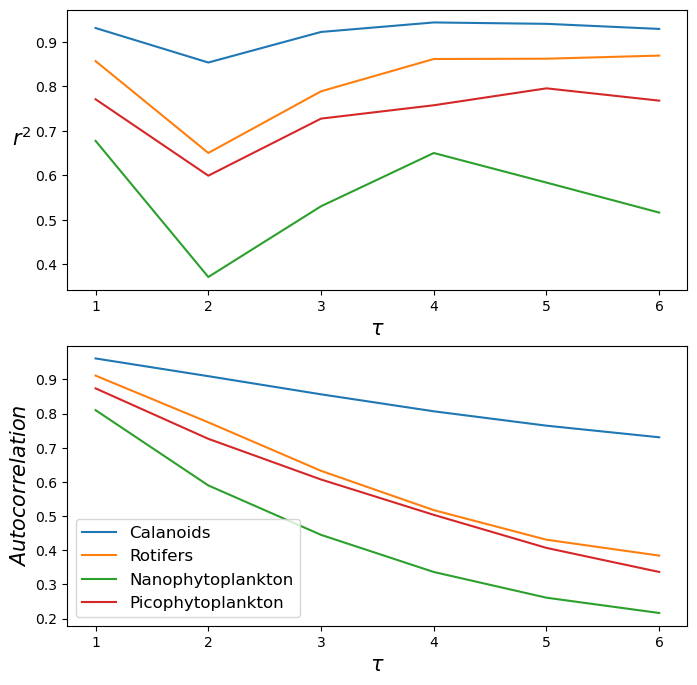

In [8]:
r_sqrd_table = np.loadtxt("../../results/baltic_sea_multiwindow/baltic_sea_rsqrd_vs_tau.csv", delimiter=",")

fig, ax = plt.subplots(2,figsize=(8,8))
for i in range(4):
    ax[0].plot(taus, r_sqrd_table[:,i], label=df.columns[i+1])
    
for i in range(4):
    ax[1].plot(taus, autocorr_table[:,i], label=df.columns[i+1])

ax[0].set_ylabel(r"$r^2$", fontsize = 15, rotation = 0, labelpad=10)
ax[0].set_xlabel(r"$\tau$", fontsize = 15, rotation = 0)

ax[1].set_xlabel(r"$\tau$", fontsize = 15, rotation = 0)
ax[1].set_ylabel(r"$Auto correlation$", fontsize = 15, rotation = 90)

plt.legend(fontsize = 12)

# Effect of Time Window on Baltic Sea Species
Now we systematically evaluate the nonstationarity of subseries of each Baltic Sea series.

In [44]:
year_steps = 27
maxLen = table[:,0].shape[0]
lengths = np.arange(year_steps*4,maxLen+1,step=year_steps)

In [45]:
# Standardize function (assumes mean/std normalization)
def standardize(ts):
    return (ts - np.mean(ts)) / np.std(ts)

In [46]:
# Load parameters from JSON file
def load_params(json_path):
    with open(json_path, 'r') as f:
        return json.load(f)

params = load_params("baltic_sea_mesocosm_params.json")

In [47]:
E_range = params["E_range"]
lambda1 = params["lambda1"]
lambda2 = params["lambda2"]
p = params["p"]
N_replicates = params["N_replicates"]
resolution = params["resolution"]
theta_range = params["theta_range"]
delta_range = params["delta_range"]

In [56]:
## Compute delta for each subseries, uncomment if you wish to run again

i = 0
species = df.columns[1:][i]

# for i, species in enumerate(df.columns[1:].to_numpy()):
ts = standardize(table[:,i+1])

E = 5
tau = 1
h = 0

# length, starting index, delta, theta, r_sqrd
n_rows = 351
results = np.zeros((n_rows, 5))
tally = 0

length = lengths[-1]
start = 0

# for length in lengths:
#     for start in np.arange(0, maxLen - length+1, step=year_steps):

ts_chunk = ts[start:length+start]
t = np.linspace(0, 1, length)

data = (standardize(ts_chunk), t, tau)
# plotTS(ts_chunk)
evidence, significance_level = nt.nonstationarity_test(
        data,
        theta_range=params["theta_range"],
        delta_range=params["delta_range"],
        E_range=params["E_range"],
        lambda1=params["lambda1"],
        lambda2=params["lambda2"],
        p=params["p"],
        resolution=params["resolution"]
)
# results[tally] = np.array([length, start, evidence, significance_level, bayes_factor_error])

In [71]:
theta_range = [0, 50]
delta_range = [0, 50]

length = lengths[-1]
start = 0

# for length in lengths:
#     for start in np.arange(0, maxLen - length+1, step=year_steps):

ts_chunk = ts[start:length+start]
t = np.linspace(0, 1, length)

data = (ts_chunk, t, tau)

In [131]:
theta, delta = nhe.compute_posterior_weighted_parameters(data, theta_range, delta_range, E_range, lambda1, lambda2, p, resolution=5)
print(theta, delta)

1.3107742227517252e-22 13.628669765675097


In [72]:
evidence, significance_level = nt.nonstationarity_test(
        data,
        theta_range=params["theta_range"],
        delta_range=params["delta_range"],
        E_range=params["E_range"],
        lambda1=params["lambda1"],
        lambda2=params["lambda2"],
        p=params["p"],
        resolution=3 # params["resolution"]
)
print(evidence, significance_level)

53.54413562011906 0.99999557832887


In [60]:
Xr, tx, tau = data

theta_values = np.linspace(theta_range[0], theta_range[1], 4)
delta_values = np.linspace(delta_range[0], delta_range[1], 4)

# Build log-likelihood grid over all E, theta, delta
log_likelihoods, E_vals, theta_vals, delta_vals = nt._build_log_likelihood_grid(
    Xr, tx, E_range, theta_values, delta_values, tau)

In [61]:
# Build prior grid: shape (len(E_vals), len(theta_vals), len(delta_vals))
prior_E_vals = np.array([nt.prior_E(E, p) for E in E_vals])
prior_theta_vals = np.array([nt.prior_1d(th, lambda1) for th in theta_vals])
prior_delta_vals = np.array([nt.prior_1d(dl, lambda2) for dl in delta_vals])
prior_grid = prior_E_vals[:, None, None] * prior_theta_vals[None, :, None] * prior_delta_vals[None, None, :]

In [62]:
# Normalize log-likelihoods for stability
log_likelihoods = log_likelihoods - np.max(log_likelihoods)

# Compute unnormalized posterior grid
posterior_grid = np.exp(log_likelihoods) * prior_grid

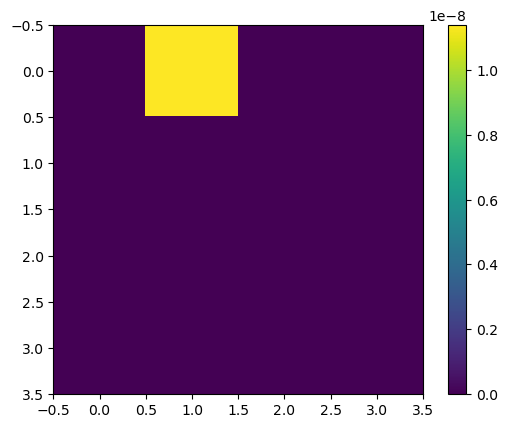

In [69]:
plt.imshow(posterior_grid[5])
plt.colorbar()

In [95]:
# Convert the delta values for each subseries into a square matrix
# which is plotted using matplotlib's imshow.
def makeHeatMapBaltic(results):
    nonstationarityHeatMap = np.zeros((29,29)) * np.nan
    for l, o, e, p, t, d in results:
        i_length = 27-(int(l / year_steps) - 2)
        i_offset = int(o / year_steps)
        # print(i_length, i_offset)
        nonstationarityHeatMap[i_length, i_offset] = max(p, 0)
        
    return nonstationarityHeatMap

In [96]:
# Make the figure
def makeFigureBaltic(nonstationarityHeatMap, ts, name, ax):
    name_to_fig_title = {"Rotifers" : "Figure_S9",
                         "Nanophytoplankton": "Figure_S10",
                         "Picophytoplankton": "Figure_S11",
                         "Calanoids": "Figure_S_unsure_yet"}
    
    scaling = lengths[-1] *3.35 / 365
    
    # im = ax.imshow(np.zeros(nonstationarityHeatMap[:-2].shape), cmap=cm.Greys)
    im = ax.imshow(nonstationarityHeatMap[:-2], cmap=custom_cmap, vmin=0, vmax=1)
    ax.set_xticks(np.arange(31,step = 30 / scaling))
    ax.set_yticks(30-365*np.arange(1,8)/3.35/26)
    ax.set_xticklabels([])
    ax.set_yticklabels(np.arange(1,8))
    ax.set_ylim(27,-1)
    ax.set_xlim(-1.3,32)
    
    ax.set_ylabel("Time series length (years)",fontsize=15)
    
    divider = make_axes_locatable(ax)
    cax = divider.append_axes('right', size='5%', pad=0.05)
    cb = plt.colorbar(im, cax=cax)
    cb.set_label(r"$p(NS)$",fontsize=15)

    axTS = divider.append_axes('bottom', size='30%', pad=0.1)

    axTS.plot(table[:,0]/365, ts,c="dodgerblue")
    axTS.set_ylabel(name,fontsize=12)
    axTS.set_xlabel("Start year",fontsize=15)
    axTS.set_yticks([])
    
    plt.savefig(f"../../figures_eps/baltic_sea_multiwindow/{name_to_fig_title[name]}.eps", format="eps", bbox_inches="tight", transparent=False, facecolor="white")
    plt.show()

In [97]:
# Make a custom orange to blue color scheme
orange_rgba = colors.to_rgba("orange")
dodgerblue_rgba = colors.to_rgba("dodgerblue")
custom_cmap = LinearSegmentedColormap.from_list("custom_cmap", [dodgerblue_rgba, orange_rgba]) 
custom_cmap.set_bad("white", 1)

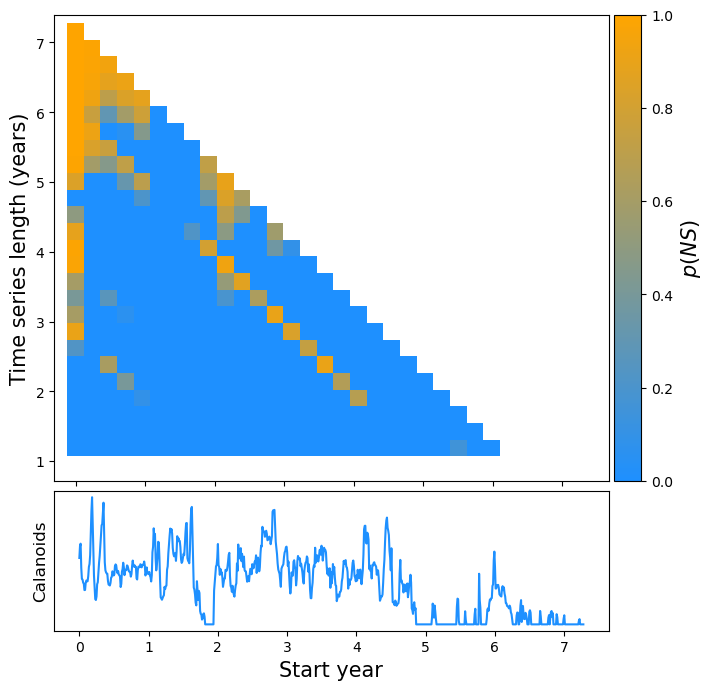

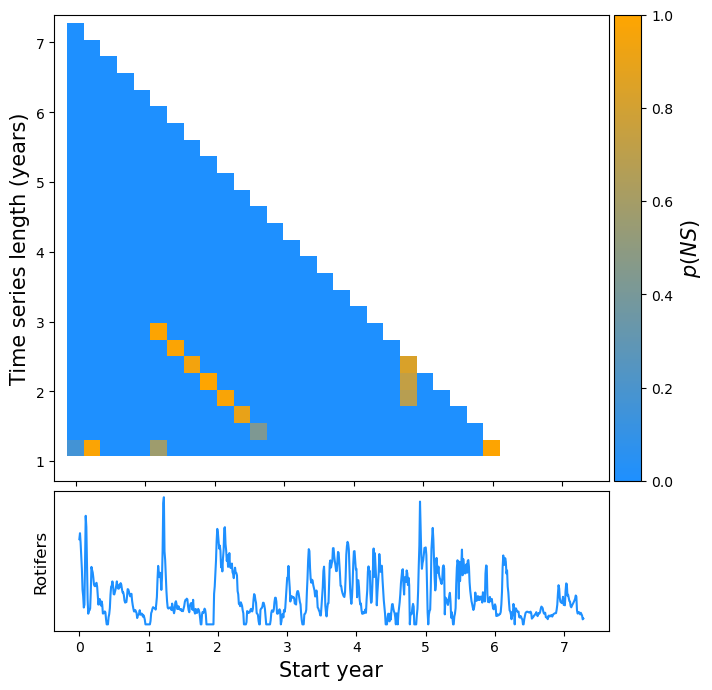

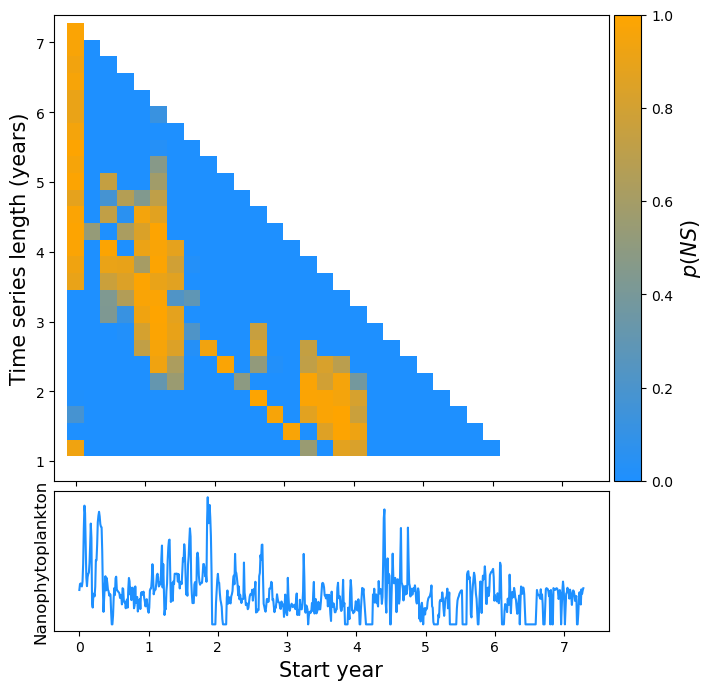

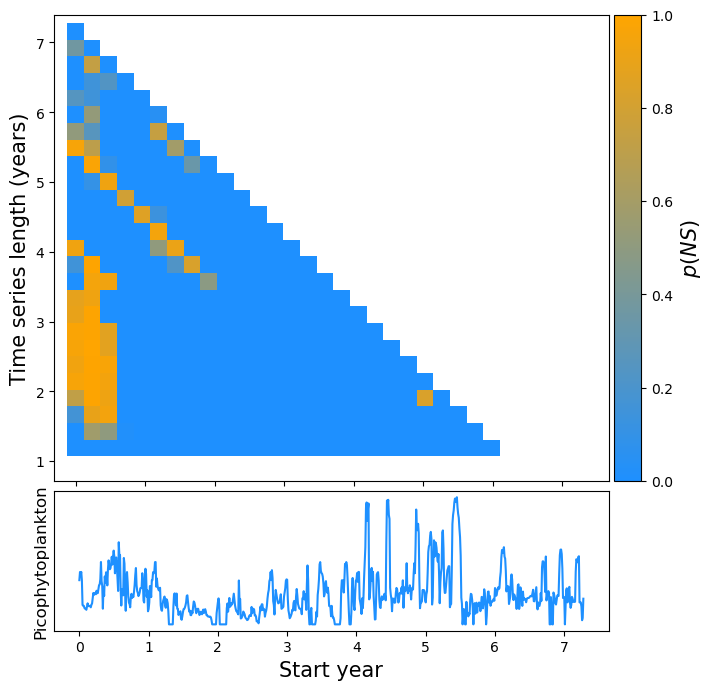

In [98]:
# Produce the figures
indices = [0,1,2,3]
year_steps = 27

for index in indices:
    figb, axb = plt.subplots(1, figsize=(8,8))
    
    species_list = ["Calanoids","Rotifers","Nanophytoplankton",
                    "Picophytoplankton"]
    results = np.loadtxt(f"../../results/baltic_sea_multiwindow/{species_list[index]}_time_window.csv",
                         delimiter=",")
    lengths = np.unique(results[:,0])
    
    ts = standardize(table[:,index+1])
    nonstationarityHeatMap = makeHeatMapBaltic(results)
    makeFigureBaltic(nonstationarityHeatMap, ts, species_list[index], axb)